In [1]:
pip install numba-cuda

In [2]:
import cv2
import numpy as np
from numba import cuda
import time
import matplotlib.pyplot as plt

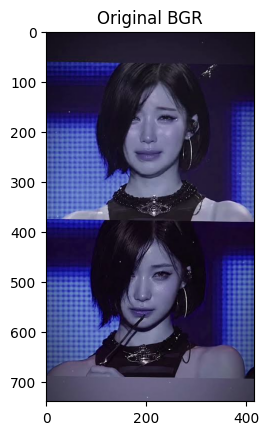

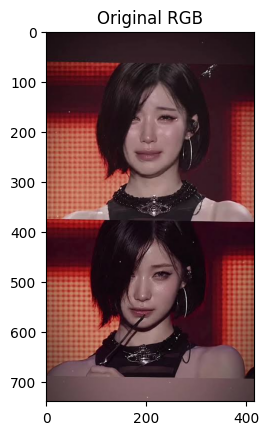

In [3]:
img = cv2.imread('/content/images.jpg')
plt.imshow(img)
plt.title("Original BGR")
plt.show()

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title("Original RGB")
plt.show()

In [4]:
height = img_rgb.shape[0]
width = img_rgb.shape[1]

print("Height:", height)
print("Width:", width)

Height: 739
Width: 415


# CPU Config

The initial code was not using int() on the for loop

EXPLAIN: RuntimeWarning: overflow encountered in scalar add
  gray_scale_img_cpu[i, j] = (R + G + B) // 3

=> Red, Green, and Blue channels directly from the uint8 array and added them together: R + G + B. If you have a bright pixel—for example, a light gray pixel where R=200, G=200, and B=200—the true mathematical sum is 600, and 600 > maximum capacity of 256 ( 0 to 255 pixel value)


- IN PAPER, for example: R = 200, G = 210, and B = 220.

    Sum: 200 + 210 + 220 = 630. Average: 630 // 3 = 210 => a bright gray

- IN REAlity:
    200 + 210 + 220 = 630. Because it cannot store 630, it overflows: 630 mod 256 = 118 => Average: 118 // 3 = 39 a very dark gray

/tmp/ipykernel_2452/4082441830.py:15: RuntimeWarning: overflow encountered in scalar add
  gray_scale_img_cpu[i, j] = (R + G + B) // 3


Time Ends:  0.4301 s


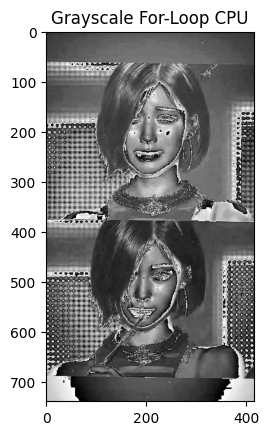

In [5]:
# ORIGINAL For loop for processing grayscale
time_start = time.time()

height = img_rgb.shape[0]
width = img_rgb.shape[1]

gray_scale_img_cpu = np.zeros((height, width), dtype=np.uint8)

for i in range(len(img_rgb)):
  for j in range(len(img_rgb[i])):
    R = img_rgb[i, j, 0]
    G = img_rgb[i, j, 1]
    B = img_rgb[i, j, 2]

    gray_scale_img_cpu[i, j] = (R + G + B) // 3

print("Time Ends: ", round(time.time() - time_start, 4), "s")

plt.imshow(gray_scale_img_cpu, cmap='gray')
plt.title("Grayscale For-Loop CPU")
plt.show()

Time Ends:  0.424 s


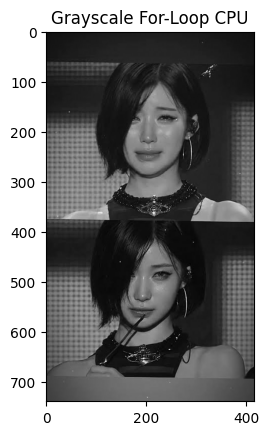

In [6]:
# For loop for processing grayscale
time_start = time.time()

height = img_rgb.shape[0]
width = img_rgb.shape[1]

gray_scale_img_cpu = np.zeros((height, width), dtype=np.uint8)

for i in range(len(img_rgb)):
  for j in range(len(img_rgb[i])):
    R = int(img_rgb[i, j, 0])
    G = int(img_rgb[i, j, 1])
    B = int(img_rgb[i, j, 2])

    gray_scale_img_cpu[i, j] = (R + G + B) // 3

print("Time Ends: ", round(time.time() - time_start, 4), "s")

plt.imshow(gray_scale_img_cpu, cmap='gray')
plt.title("Grayscale For-Loop CPU")
plt.show()

# GPU Config

In [7]:
# Original
time_start = time.time()


height = img_rgb.shape[0]
width = img_rgb.shape[1]

pixelCount = width * height
blockSize = 64
gridSize = pixelCount / blockSize

src_host = np.ascontiguousarray(img_rgb.reshape(pixelCount, 3))

@cuda.jit
def grayscale(src, dst):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    s = int(src[tidx, 0]) + int(src[tidx, 1]) + int(src[tidx, 2])
    g = np.uint8(s // 3)
    dst[tidx, 0] = g
    dst[tidx, 1] = g
    dst[tidx, 2] = g

devSrc = cuda.to_device(src_host)
devDst = cuda.device_array((pixelCount, 3), np.uint8)

grayscale[gridSize, blockSize](devSrc, devDst)
cuda.synchronize()

hostDst = devDst.copy_to_host().reshape(height, width, 3)

time_end = time.time()
print("Time:", round(time_end - time_start, 4), "s")

plt.imshow(hostDst)  # 3 equal channels, so it displays as gray
plt.title("Grayscale GPU")
plt.axis('off')
plt.show()


TypeError: griddim must be a sequence of integers, got [4791.953125]

In [8]:
height = img_rgb.shape[0]
width = img_rgb.shape[1]

pixelCount = width * height
print("Pixel Count: ", pixelCount)

blockSize = 64 # Slide Configuration
gridSize = pixelCount / blockSize

print("Grid Size: ", gridSize) # Type: Float: 14400.0

Pixel Count:  306685
Grid Size:  4791.953125


call grayscale[gridSize, blockSize] => This function telling to take the exact physical blocks of threads ( Here 14400, but 14400.0 so OOF! => TypeError)



Solution: gridSize = (pixelCount + blockSize - 1) // blockSize

In [9]:
gridSize = (pixelCount + blockSize - 1) // blockSize

print("Grid Size: ", gridSize) # Type: Int: 1440

Grid Size:  4792


Time: 1.9295 s


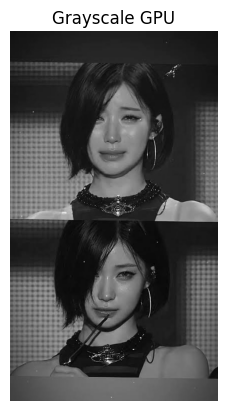

In [10]:

time_start = time.time()


height = img_rgb.shape[0]
width = img_rgb.shape[1]

pixelCount = width * height
blockSize = 64
# gridSize = pixelCount / blockSize
gridSize = (pixelCount + blockSize - 1) // blockSize

src_host = img_rgb.reshape(pixelCount, 3)

@cuda.jit
def grayscale(src, dst):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    s = int(src[tidx, 0]) + int(src[tidx, 1]) + int(src[tidx, 2])
    g = np.uint8(s // 3)
    dst[tidx, 0] = g
    dst[tidx, 1] = g
    dst[tidx, 2] = g

devSrc = cuda.to_device(src_host)
devDst = cuda.device_array((pixelCount, 3), np.uint8)

grayscale[gridSize, blockSize](devSrc, devDst)
cuda.synchronize()

hostDst = devDst.copy_to_host().reshape(height, width, 3)

time_end = time.time()
print("Time:", round(time_end - time_start, 4), "s")

plt.imshow(hostDst)
plt.title("Grayscale GPU")
plt.axis('off')
plt.show()
